In [140]:
%pip install qiskit
%pip install qiskit_aer
%pip install numpy
%pip install matplotlib
%pip install pylatexenc


In [141]:
%matplotlib inline

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, random_unitary
from qiskit.circuit.library.data_preparation import Initialize
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.circuit.library import IGate, XGate, ZGate

from qiskit_aer import Aer, AerSimulator
from qiskit.quantum_info import partial_trace
backend = AerSimulator(method='statevector')

In [142]:
# EXERCICIO 1 (Preparação de estado)
qc = QuantumCircuit(3, 1)

qc.ry(np.pi/3, 0)
qc.measure(0, 0)

qc.draw()

┌─────────┐┌─┐
q_0: ┤ Ry(π/3) ├┤M├
     └─────────┘└╥┘
q_1: ────────────╫─
                 ║ 
q_2: ────────────╫─
                 ║ 
c: 1/════════════╩═
                 0

{'1': 503, '0': 1545}
Percentagem de medições |0⟩ no primeiro qubit: 75.44%


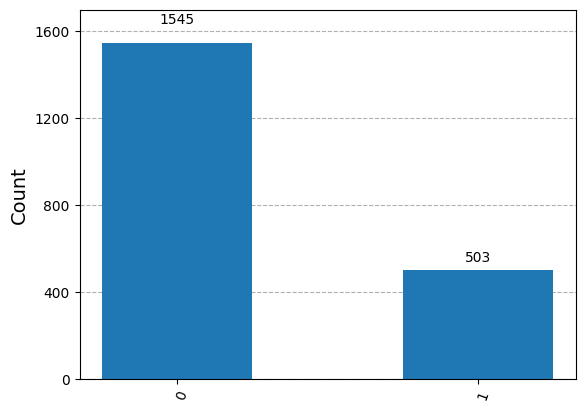

In [143]:
# Verificar que há 75% de probabilidade de medir |0> no primeiro qubit
job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()
print(counts)

# Contar as ocorrências de |0> no primeiro qubit
num_zeros = sum(count for state, count in counts.items() if state[-1] == '0')
total_shots = sum(counts.values())
percent_zeros = (num_zeros / total_shots) * 100

# Exibir os resultados
print(f"Percentagem de medições |0⟩ no primeiro qubit: {percent_zeros:.2f}%")

plot_histogram(counts)


In [144]:
#EXERCICIO 2 (Erro do tipo Y)
# Circuito igual mas com a operação Y no estado final
qc = QuantumCircuit(3, 1)

qc.ry(np.pi/3, 0)

qc.y(0)
qc.measure(0, 0)

qc.draw()




┌─────────┐┌───┐┌─┐
q_0: ┤ Ry(π/3) ├┤ Y ├┤M├
     └─────────┘└───┘└╥┘
q_1: ─────────────────╫─
                      ║ 
q_2: ─────────────────╫─
                      ║ 
c: 1/═════════════════╩═
                      0

{'0': 514, '1': 1534}
Percentagem de medições |0⟩ no primeiro qubit: 25.10%
Percentagem de medições |1⟩ no primeiro qubit: 74.90%


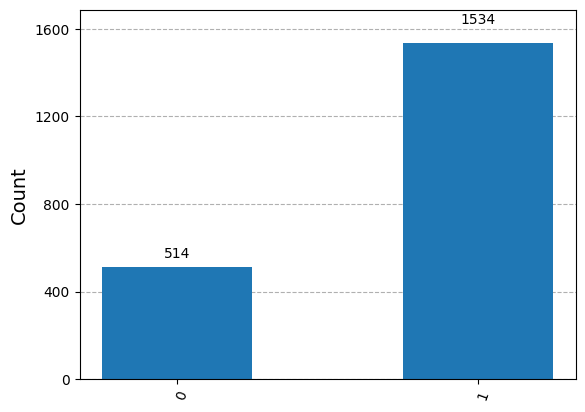

In [145]:
# Verificar que há 75% de probabilidade de medir |1> no primeiro qubit
job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()
print(counts)

# Contar as ocorrências de |0> e |1> no primeiro qubit
num_zeros = sum(count for state, count in counts.items() if state[-1] == '0')
total_shots = sum(counts.values())
percent_zeros = (num_zeros / total_shots) * 100
num_ones = sum(count for state, count in counts.items() if state[-1] == '1')
percent_ones = (num_ones / total_shots) * 100


# Exibir os resultados
print(f"Percentagem de medições |0⟩ no primeiro qubit: {percent_zeros:.2f}%")
print(f"Percentagem de medições |1⟩ no primeiro qubit: {percent_ones:.2f}%")

plot_histogram(counts)

Após a introdução do erro Y as probabilidades de medir o quibit no estado $$P(|0 \rangle) = 0.25 $$

Para proteger contra erros do tipo Y, vamos usar a relação $$S^{\dagger}YS = X$$ sendo S a operação associada à matriz: $$S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}$$e sendo i a unidade imaginária.


In [146]:
#EXERCICIO 3 (Correção de erros)
def erro_y(qubit):
    qc = QuantumCircuit(3, 1)
    qc.ry(np.pi/3, 0)
    qc.cx(0, 1)
    qc.cx(0, 2)

    qc.s(range(3))

    qc.barrier()
    if(qubit != -1):
        qc.y(qubit)
    qc.barrier()

    qc.sdg(range(3))

    qc.cx(0, 2)
    qc.cx(0, 1)
    qc.ccx(2, 1, 0)

    qc.measure(0, 0)

    return qc

In [147]:
#(a)
qc = erro_y(-1)

#circuito
qc.draw()

┌─────────┐          ┌───┐ ░  ░ ┌─────┐          ┌───┐┌─┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░──░─┤ Sdg ├──■────■──┤ X ├┤M├
     └─────────┘┌─┴─┐  │  ├───┤ ░  ░ ├─────┤  │  ┌─┴─┐└─┬─┘└╥┘
q_1: ───────────┤ X ├──┼──┤ S ├─░──░─┤ Sdg ├──┼──┤ X ├──■───╫─
                └───┘┌─┴─┐├───┤ ░  ░ ├─────┤┌─┴─┐└───┘  │   ║ 
q_2: ────────────────┤ X ├┤ S ├─░──░─┤ Sdg ├┤ X ├───────■───╫─
                     └───┘└───┘ ░  ░ └─────┘└───┘           ║ 
c: 1/═══════════════════════════════════════════════════════╩═
                                                            0

{'1': 517, '0': 1531}


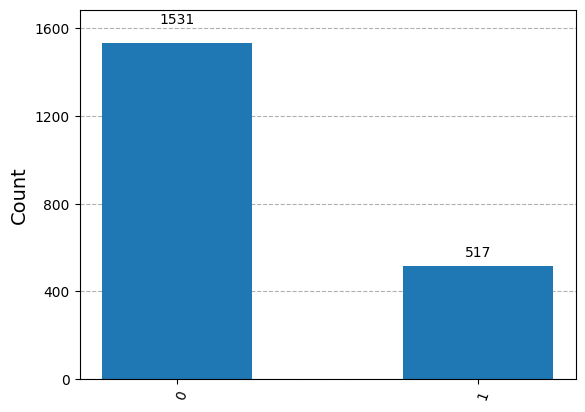

In [148]:
job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

In [149]:
# 3(b)

qc = erro_y(0)
qc.draw()

┌─────────┐          ┌───┐ ░ ┌───┐ ░ ┌─────┐          ┌───┐┌─┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░─┤ Y ├─░─┤ Sdg ├──■────■──┤ X ├┤M├
     └─────────┘┌─┴─┐  │  ├───┤ ░ └───┘ ░ ├─────┤  │  ┌─┴─┐└─┬─┘└╥┘
q_1: ───────────┤ X ├──┼──┤ S ├─░───────░─┤ Sdg ├──┼──┤ X ├──■───╫─
                └───┘┌─┴─┐├───┤ ░       ░ ├─────┤┌─┴─┐└───┘  │   ║ 
q_2: ────────────────┤ X ├┤ S ├─░───────░─┤ Sdg ├┤ X ├───────■───╫─
                     └───┘└───┘ ░       ░ └─────┘└───┘           ║ 
c: 1/════════════════════════════════════════════════════════════╩═
                                                                 0

{'1': 513, '0': 1535}


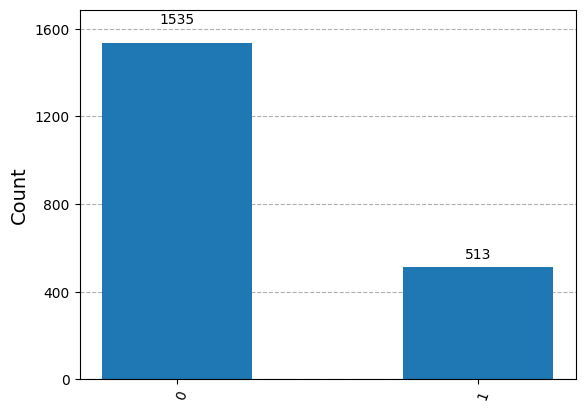

In [150]:
job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

In [151]:
# 3 (c)
qc = erro_y(1)
qc.draw()

┌─────────┐          ┌───┐ ░       ░ ┌─────┐          ┌───┐┌─┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░───────░─┤ Sdg ├──■────■──┤ X ├┤M├
     └─────────┘┌─┴─┐  │  ├───┤ ░ ┌───┐ ░ ├─────┤  │  ┌─┴─┐└─┬─┘└╥┘
q_1: ───────────┤ X ├──┼──┤ S ├─░─┤ Y ├─░─┤ Sdg ├──┼──┤ X ├──■───╫─
                └───┘┌─┴─┐├───┤ ░ └───┘ ░ ├─────┤┌─┴─┐└───┘  │   ║ 
q_2: ────────────────┤ X ├┤ S ├─░───────░─┤ Sdg ├┤ X ├───────■───╫─
                     └───┘└───┘ ░       ░ └─────┘└───┘           ║ 
c: 1/════════════════════════════════════════════════════════════╩═
                                                                 0

{'1': 514, '0': 1534}


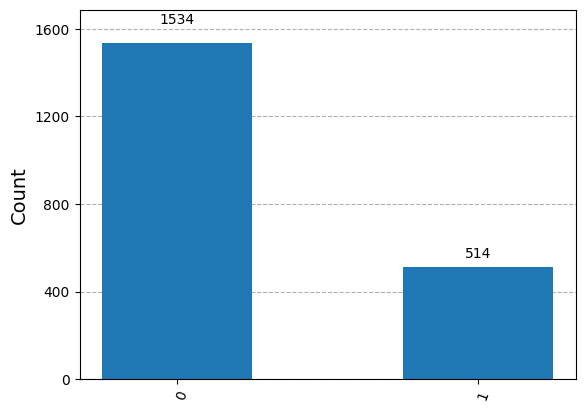

In [152]:
job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

In [153]:
# 3 (d)
qc = erro_y(2)
qc.draw()

┌─────────┐          ┌───┐ ░       ░ ┌─────┐          ┌───┐┌─┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░───────░─┤ Sdg ├──■────■──┤ X ├┤M├
     └─────────┘┌─┴─┐  │  ├───┤ ░       ░ ├─────┤  │  ┌─┴─┐└─┬─┘└╥┘
q_1: ───────────┤ X ├──┼──┤ S ├─░───────░─┤ Sdg ├──┼──┤ X ├──■───╫─
                └───┘┌─┴─┐├───┤ ░ ┌───┐ ░ ├─────┤┌─┴─┐└───┘  │   ║ 
q_2: ────────────────┤ X ├┤ S ├─░─┤ Y ├─░─┤ Sdg ├┤ X ├───────■───╫─
                     └───┘└───┘ ░ └───┘ ░ └─────┘└───┘           ║ 
c: 1/════════════════════════════════════════════════════════════╩═
                                                                 0

{'1': 537, '0': 1511}


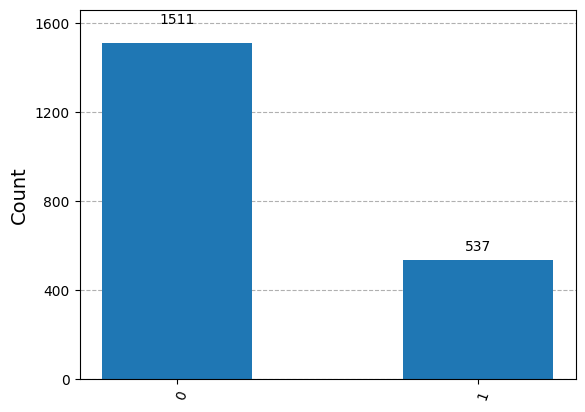

In [154]:
job = backend.run(qc, shots=2048)
result = job.result()
counts = result.get_counts()
print(counts)
plot_histogram(counts)

Devido à inalteração das medições verifica-se que os erros do tipo Y estão a ser corrigidos

In [155]:
def formata(z):
    if abs(z) < 1e-10: return "0"
    if z.imag == 0: return f"{z.real:.3f}"
    if z.real == 0: return f"{z.imag:.3f}i"
    return f"{z.real:.3f}{'+' if z.imag >= 0 else ''}{z.imag:.3f}i"

def estado(qc, step_name=""):
    backend = Aer.get_backend('statevector_simulator')
    job = backend.run(qc)
    result = job.result()
    sv = np.asarray(result.get_statevector())

    print(f"\n{step_name}")

    state = "|ψ⟩ = "
    n_qubits = len(qc.qubits)

    for i, amp in enumerate(sv):
        if abs(amp) > 1e-10:
            basis = format(i, f'0{n_qubits}b')
            if state != "|ψ⟩ = ":
                state += " + " if amp.real >= 0 else " - "
            state += f"({formata(abs(amp) if amp.real < 0 else amp)})|{basis}⟩"

    print(state)
    print("\nProbabilidades de medição:")
    for i, amp in enumerate(sv):
        prob = abs(amp)**2
        if prob > 1e-10:
            basis = format(i, f'0{n_qubits}b')
            print(f"P(|{basis}⟩) = {prob:.3f}")

Diferentes etapas do circuito:


In [156]:
#etapa 1:

qc = QuantumCircuit(3, 1)
qc.ry(np.pi/3, 0)

estado(qc, "Inicial")
qc.draw()

# Como verificado no primeiro exercício, após aplicar uma rotação em Y de pi/3, a probabilidade de medir o estado |0> no primeiro quibit é de 75%


Inicial
|ψ⟩ = (0.866)|000⟩ + (0.500)|001⟩

Probabilidades de medição:
P(|000⟩) = 0.750
P(|001⟩) = 0.250


┌─────────┐
q_0: ┤ Ry(π/3) ├
     └─────────┘
q_1: ───────────
                
q_2: ───────────
                
c: 1/═══════════

In [157]:
#etapa2
qc.cx(0, 1)
qc.cx(0, 2)

estado(qc, "Com CNOTs")
qc.draw()

#Como o primeiro qubit é o qubit de controle das operações CNOT, o seu estado afeta os outros dois qubits. A probabilidade deste ser |1> é passada para os outros 2 qubits.


Com CNOTs
|ψ⟩ = (0.866)|000⟩ + (0.500)|111⟩

Probabilidades de medição:
P(|000⟩) = 0.750
P(|111⟩) = 0.250


┌─────────┐          
q_0: ┤ Ry(π/3) ├──■────■──
     └─────────┘┌─┴─┐  │  
q_1: ───────────┤ X ├──┼──
                └───┘┌─┴─┐
q_2: ────────────────┤ X ├
                     └───┘
c: 1/═════════════════════

In [158]:
#etapa3
qc.s(range(3))
qc.barrier()
qc.y(0)
qc.barrier()
qc.sdg(range(3))

estado(qc, "Após gates S")
qc.draw()

#Sabemos que Sdg*Y*S = X e que Sdg*S = I. Portanto, no qubit onde o erro foi aplicado, esse erro fica a ser um erro de X (ou seja, um bit-flip).
#Como resultado, a probabilidade de medir ∣1⟩ no primeiro qubit passa a ser 75%. Nos demais qubits, o estado permanece inalterado.

# Este tipo de erro (bit-flip) é corrigível com o código de Shor:


Após gates S
|ψ⟩ = (0.866)|001⟩ + (0.500)|110⟩

Probabilidades de medição:
P(|001⟩) = 0.750
P(|110⟩) = 0.250


┌─────────┐          ┌───┐ ░ ┌───┐ ░ ┌─────┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░─┤ Y ├─░─┤ Sdg ├
     └─────────┘┌─┴─┐  │  ├───┤ ░ └───┘ ░ ├─────┤
q_1: ───────────┤ X ├──┼──┤ S ├─░───────░─┤ Sdg ├
                └───┘┌─┴─┐├───┤ ░       ░ ├─────┤
q_2: ────────────────┤ X ├┤ S ├─░───────░─┤ Sdg ├
                     └───┘└───┘ ░       ░ └─────┘
c: 1/════════════════════════════════════════════

In [159]:
#ultima etapa
qc.cx(0, 2)
qc.cx(0, 1)
qc.ccx(2, 1, 0)
estado(qc, "Após CNOTs finais")
qc.draw()

# Por fim aplicamos os CNOTs para desfazer a operação inicial de controlo,
# Isto resulta num estado no qual a probabilidade de medir |0> no primeiro qubit volta a ser 75%


Após CNOTs finais
|ψ⟩ = (0.866)|110⟩ + (0.500)|111⟩

Probabilidades de medição:
P(|110⟩) = 0.750
P(|111⟩) = 0.250


┌─────────┐          ┌───┐ ░ ┌───┐ ░ ┌─────┐          ┌───┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░─┤ Y ├─░─┤ Sdg ├──■────■──┤ X ├
     └─────────┘┌─┴─┐  │  ├───┤ ░ └───┘ ░ ├─────┤  │  ┌─┴─┐└─┬─┘
q_1: ───────────┤ X ├──┼──┤ S ├─░───────░─┤ Sdg ├──┼──┤ X ├──■──
                └───┘┌─┴─┐├───┤ ░       ░ ├─────┤┌─┴─┐└───┘  │  
q_2: ────────────────┤ X ├┤ S ├─░───────░─┤ Sdg ├┤ X ├───────■──
                     └───┘└───┘ ░       ░ └─────┘└───┘          
c: 1/═══════════════════════════════════════════════════════════

Deste modo e com estes circuitos, o erro de Y no qubit é corrigido.
O qubit de controlo é utilizado para propagar o erro para os outros qubits, e, em seguida, os outros qubits são usados para corrigir o erro no qubit original de controlo.

Isto funciona desde que o erro não ocorra em mais do que 1 qubit ao mesmo tempo. O processo baseia-se num majority vote (a decisão final sobre o estado de um qubit é tomada com base no estado que ocorre com maior frequência entre vários qubits) para determinar o estado correto.

In [162]:
#EXERCICIO 4 (Erros genéricos)

#circuito para corrigir erros genéricos, não só erros de Y, mas também erros de X e Z

# Erro X: |0> -> |1> e |1> -> |0>
# Erro Z: |+> -> |-> e |-> -> |+>
# Erro Y: |i> -> -|i> e |-i> -> -|-i> (Y = iXZ)

qc = QuantumCircuit(3, 1)
qc.ry(np.pi/3, 0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.s(range(3))

qc.barrier()
qc.y(0)
qc.barrier()

qc.sdg(range(3))

qc.cx(0, 2)
qc.cx(0, 1)
qc.ccx(2, 1, 0)

qc.barrier()

# Medir o qubit 0
qc.measure(0, 0)

# Desenhar o circuito
qc.draw()

┌─────────┐          ┌───┐ ░ ┌───┐ ░ ┌─────┐          ┌───┐ ░ ┌─┐
q_0: ┤ Ry(π/3) ├──■────■──┤ S ├─░─┤ Y ├─░─┤ Sdg ├──■────■──┤ X ├─░─┤M├
     └─────────┘┌─┴─┐  │  ├───┤ ░ └───┘ ░ ├─────┤  │  ┌─┴─┐└─┬─┘ ░ └╥┘
q_1: ───────────┤ X ├──┼──┤ S ├─░───────░─┤ Sdg ├──┼──┤ X ├──■───░──╫─
                └───┘┌─┴─┐├───┤ ░       ░ ├─────┤┌─┴─┐└───┘  │   ░  ║ 
q_2: ────────────────┤ X ├┤ S ├─░───────░─┤ Sdg ├┤ X ├───────■───░──╫─
                     └───┘└───┘ ░       ░ └─────┘└───┘           ░  ║ 
c: 1/═══════════════════════════════════════════════════════════════╩═
                                                                    0